In [1]:
import torch
import torchphysics as tp
import pandas as pd
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch.utils.data import DataLoader
import pytorch_lightning as pl
import os
from pytorch_lightning import loggers as pl_loggers



/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Define dimensions

In [2]:
#Input
X = tp.spaces.R1('x')
Y = tp.spaces.R1('y')
C = tp.spaces.R1("c") # number of case
#output
U = tp.spaces.R1('u')
V = tp.spaces.R1('v')
URMS = tp.spaces.R1('urms')
VRMS = tp.spaces.R1('vrms')
UV=tp.spaces.R1('uv')
P=tp.spaces.R1('p')

# Here

In [3]:
DF_Data=pd.read_csv("Data/Flow_3d_2289_6_Cx3_Cy3X240Y76_half.csv")
len(DF_Data[(DF_Data.c==0)&(DF_Data.y<0.4)]["y"].unique())

45

# PIAN parameters

# Here


In [4]:
# GAN macros
GPU="cuda:0"
GAN_weight=1 # Generator weight
L_x=3.6 # length of domain
N_x=240 # grid in x
N_x_sub=72
N_y_F=76 # grid in y
y_lim=0.50
N_y_sub=len(DF_Data[(DF_Data.c==0)&(DF_Data.y<y_lim)]["y"].unique())
N_dists=1 # N 1d roughness for fake images during trainingN_epochs
N_epochs=100 # N training iteration each epoch
GP_weight=10
Grid_data=False


In [5]:
X_interval = tp.domains.Interval(X, 0, L_x) # <-add the bounds of the Interval (0, 2)
Y_interval = tp.domains.Interval(Y, 0, 1.0)
C_interval = tp.domains.Interval(C,0,288) # number of available roughness profiles

Sim_domain = X_interval*Y_interval*C_interval


Y_interval_sub_low=tp.domains.Interval(Y, 0, 0.15)
Sim_domain_sub_low=X_interval*Y_interval_sub_low*C_interval
#Y_interval_sub_up=tp.domains.Interval(Y, 2-0.15, 2)
#Sim_domain_sub_up=X_interval*Y_interval_sub_up*C_interval

### Read DNS data for discriminator

In [6]:
#DF_Data=pd.read_csv("Data/Flow_3d_2289_6_Cx3_Cy3X240Y76_half.csv")


In [7]:
#DF=DF_Data[["U","V","urms","vrms","uv",]]

In [8]:
N_c=len(DF_Data["c"].unique()) # number of available training data

# Here

In [9]:
DF_vincinity=DF_Data[(DF_Data.y<y_lim)]

In [10]:
DF_vincinity

,x,y,c,U,V,urms,vrms,uv
0,0.000,0.000000,0,2.600656e-15,-3.692872e-18,2.140123e-13,8.047987e-16,-1.577949e-29
1,0.000,0.000219,0,-1.642957e-05,-3.893802e-08,5.789438e-03,2.496284e-05,-4.802864e-08
2,0.000,0.000877,0,-7.122126e-06,4.101823e-07,1.945061e-02,3.547416e-04,-2.402340e-06
3,0.000,0.001973,0,-1.232326e-06,1.305334e-06,3.354623e-02,1.503424e-03,-1.795480e-05
4,0.000,0.003507,0,7.461424e-06,5.318665e-06,4.319456e-02,3.807695e-03,-6.038412e-05
...,...,...,...,...,...,...,...,...
5253089,3.585,0.412215,287,1.551821e+00,-7.067616e-05,1.306064e+00,7.977620e-01,-7.465464e-01
5253090,3.585,0.429286,287,1.570027e+00,1.179105e-03,1.295248e+00,7.993113e-01,-7.340152e-01
5253091,3.585,0.446609,287,1.588562e+00,2.238681e-03,1.274001e+00,7.901534e-01,-7.036563e-01
5253092,3.585,0.464173,287,1.608841e+00,2.641598e-03,1.237470e+00,7.837104e-01,-6.831927e-01


In [11]:
N_c*200*45*5

12960000

In [12]:
len(DF_vincinity)/(288*200)

60.0

In [13]:
DF_vincinity[["U","V","urms","vrms","uv"]].to_numpy().transpose((1,0)).reshape((5,-1))

array([[ 2.600656e-15, -1.642957e-05, -7.122126e-06, ...,  1.588562e+00,
         1.608841e+00,  1.627663e+00],
       [-3.692872e-18, -3.893802e-08,  4.101823e-07, ...,  2.238681e-03,
         2.641598e-03,  2.400188e-03],
       [ 2.140123e-13,  5.789438e-03,  1.945061e-02, ...,  1.274001e+00,
         1.237470e+00,  1.202476e+00],
       [ 8.047987e-16,  2.496284e-05,  3.547416e-04, ...,  7.901534e-01,
         7.837104e-01,  7.725503e-01],
       [-1.577949e-29, -4.802864e-08, -2.402340e-06, ..., -7.036563e-01,
        -6.831927e-01, -6.664660e-01]])

# Formulating data matrix components * cases * LX * LY

In [14]:
#Data_Pinn=torch.tensor(DF_Data[["U","V","urms","vrms","uv"]].to_numpy().transpose((1,0)).reshape((5,N_c,N_x,N_y)),dtype=torch.float32,device=GPU)
#Data_Pinn=Data_Pinn.transpose(1,0)

# here

In [15]:
Data_Pinn=torch.permute(torch.tensor(DF_vincinity[["U","V","urms","vrms","uv"]].to_numpy(),dtype=torch.float32,device=GPU).reshape((N_c,N_x,N_y_sub,5)),(0,3,1,2))


In [16]:
Data_Pinn.shape

torch.Size([288, 5, 240, 50])

 # Calculation of y gird

In [17]:
ys=DF_vincinity["y"].unique()

In [18]:
ys

array([0.000000e+00, 2.193165e-04, 8.771699e-04, 1.973272e-03,
       3.507141e-03, 5.478105e-03, 7.885299e-03, 1.072767e-02,
       1.400396e-02, 1.771275e-02, 2.185240e-02, 2.642110e-02,
       3.141684e-02, 3.683743e-02, 4.268050e-02, 4.894348e-02,
       5.562363e-02, 6.271801e-02, 7.022351e-02, 7.813685e-02,
       8.645454e-02, 9.517295e-02, 1.042882e-01, 1.137964e-01,
       1.236933e-01, 1.339746e-01, 1.446357e-01, 1.556721e-01,
       1.670788e-01, 1.788508e-01, 1.909830e-01, 2.034701e-01,
       2.163065e-01, 2.294868e-01, 2.430049e-01, 2.568552e-01,
       2.710314e-01, 2.855273e-01, 3.003367e-01, 3.154529e-01,
       3.308694e-01, 3.465794e-01, 3.625760e-01, 3.788522e-01,
       3.954009e-01, 4.122147e-01, 4.292864e-01, 4.466085e-01,
       4.641732e-01, 4.819730e-01])

In [19]:

#if Grid_data:
#    ys=torch.linspace(0,1,N_y,dtype=torch.float32,device=GPU)
#else:
#    eta=torch.cos(torch.pi*(torch.tensor([i for i in range(N_y_F*2)],device=GPU))/(N_y_F*2-1)) 
#    ys=(1-eta.detach())[:N_y_sub]


In [20]:
ys=torch.tensor(ys,dtype=torch.float32,device=GPU)

# interpolating dist to required resolution based on N_x

In [21]:
DF_DIST=pd.read_csv("Data/dist_2289_1Ds.csv",header=None)
x_corr=DF_DIST.iloc[0].to_numpy()
dist=DF_DIST.iloc[1:].to_numpy()
x_corr_new=np.linspace(min(x_corr),max(x_corr),N_x)
dist_new=np.zeros((len(dist),N_x))
for i in range(len(dist)):
    dist_new[i,:]=np.interp(x_corr_new,x_corr,dist[i])
x_corr_new=torch.tensor(x_corr_new,requires_grad=False, dtype=torch.float32,device=GPU)
x_corr=torch.tensor(x_corr,requires_grad=False, dtype=torch.float32,device=GPU)
dist_new=torch.tensor(dist_new,requires_grad=False, dtype=torch.float32,device=GPU)
dist=torch.tensor(dist, requires_grad=False,dtype=torch.float32,device=GPU)

In [22]:
ymesh=ys.reshape((1,1,1,-1)).expand((N_c,1,N_x,-1))


In [23]:
matrix_mask_Data=(ymesh<dist_new.reshape((N_c,1,N_x,-1)))|(ymesh>=(2-dist_new.reshape((N_c,1,N_x,-1))))
matrix_mask_Data=matrix_mask_Data.long()

In [24]:
ymesh.shape

torch.Size([288, 1, 240, 50])

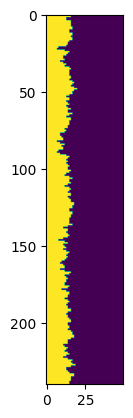

In [25]:
plt.imshow(matrix_mask_Data[1,0,:,:].cpu())

## Define repository of roughness distributions (1d)  
TODO: link repo_dist to togography repository

In [26]:
repo_dist=dist
repo_dist_new=dist_new#
#np.zeros((len(repo_dist),N_x))
#for i in range(len(repo_dist)):
#    repo_dist_new[i,:]=np.interp(x_corr_new,x_corr,repo_dist[i])


# IBM boundary sampler

In [27]:
def IBM_irr_filter_low(x,y,c):
    position_r=torch.tensor([sum(x_corr<x_i)-1 for x_i in x],device=GPU)
    #position_r=sum(x_corr<x)
    position_l=position_r-1
    x_new=torch.transpose(x,1,0)[0]
    c_new=torch.transpose(c,1,0)[0]
    c_new = c_new.to(torch.long)
    height=dist[c_new,position_l]+(dist[c_new,position_r]-dist[c_new,position_l])*(x_new-x_corr[position_l])/(x_corr[position_r]-x_corr[position_l])
    #print(height.shape)
    return (y[...,0]<=height)
IBM_sampler_irr_low = tp.samplers.RandomUniformSampler(Sim_domain_sub_low,n_points=1000,filter_fn=IBM_irr_filter_low).make_static(resample_interval=2000)



# Fluid domain sampler

In [28]:
def Inner_filter(x,y,c):
    position_r=torch.tensor([sum(x_corr<x_i)-1 for x_i in x],device=GPU)
    #position_r=sum(x_corr<x)
    position_l=position_r-1
    x_new=torch.transpose(x,1,0)[0]
    c_new=torch.transpose(c,1,0)[0]
    c_new = c_new.to(torch.long)
    height=dist[c_new,position_l]+(dist[c_new,position_r]-dist[c_new,position_l])*(x_new-x_corr[position_l])/(x_corr[position_r]-x_corr[position_l])
    return (y[...,0]>height)
inner_sampler = tp.samplers.RandomUniformSampler(Sim_domain, n_points=2000,filter_fn=Inner_filter).make_static(resample_interval=2000)#,filter_fn=Inner_filter)


In [29]:
bound_sampler_up = tp.samplers.RandomUniformSampler(X_interval*Y_interval.boundary_right*C_interval, n_points=500)



In [30]:
#a=inner_sampler.sample_points()

In [31]:
#(a.coordinates["c"]>10).reshape(-1)

In [32]:
#a[[(a.coordinates["c"]>10).reshape(-1)]]

# Log-layer sampler

In [33]:
def Log_filter(x,y,c):
    return (y[...,0]>0.5)
log_sampler = tp.samplers.RandomUniformSampler(Sim_domain, n_points=500,filter_fn=Log_filter).make_static(resample_interval=200)#,filter_fn=Inner_filter)


# PINN model with Fourier feature extraction  & CNN

In [34]:
def self_sin(input):
    return input.sin()
def self_cos(input):
    return input.cos()

In [35]:
import torch.nn as nn
import torch.nn.functional as F
torch.manual_seed(seed=42)
class FCN_model_Fourier_Feature_CNN(nn.Module):
    def __init__(self,input_space,output_space,N_features,sigma_1=1,sigma_2=15):
        super().__init__()
        self.W_1 =torch.randn(input_space.dim , N_features //2, dtype=torch.float32,device=GPU).to(torch.float32).requires_grad_(False) * sigma_1
        self.W_2 = torch.randn(input_space.dim , N_features //2, dtype=torch.float32,device=GPU).to(torch.float32).requires_grad_(False) * sigma_2
        self.register_buffer("selfW1", self.W_1, persistent=False)
        self.register_buffer("selfW2", self.W_2, persistent=False)
        self.output_space=output_space
        self.fc1_l=nn.Linear(in_features=N_features,out_features=150,device=GPU)
        self.fc2_l=nn.Linear(in_features=150,out_features=150,device=GPU)
        self.fc3_l=nn.Linear(in_features=150,out_features=150,device=GPU)
        ###
        self.fc1_r=nn.Linear(in_features=N_features,out_features=150,device=GPU)
        self.fc2_r=nn.Linear(in_features=150,out_features=150,device=GPU)
        self.fc3_r=nn.Linear(in_features=150,out_features=150,device=GPU)


        self.conv1=nn.Conv1d(1,5,3,stride=1,padding=1,device=GPU) #((720-3+2*1)/1)+1 *8=720 *5
        self.act1=nn.LeakyReLU(0.1)
        #self.pool1=nn.MaxPool1d(kernel_size=2) # stride=2   (720-2)/2 + 1 *8 = 360 *3
        
        self.conv2=nn.Conv1d(5,9,3,stride=1,padding=1,device=GPU) # ((720-3+2*1)/1)+1 *32 = 720*9
        self.act2=nn.LeakyReLU(0.1)
        #self.pool2=nn.MaxPool1d(kernel_size=2) #360*6

        self.conv3=nn.Conv1d(9,15,5,stride=3,padding=1,device=GPU) #((720-5+2*1)/3)+1 *32 = 240*15
        self.act3=nn.LeakyReLU(0.1)
        self.pool3=nn.MaxPool1d(kernel_size=2)# 120*9
        self.conv4=nn.Conv1d(15,20,5,stride=3,padding=1,device=GPU) #((120-5+2*1)/3)+1 *32 = 40*20
        self.act4=nn.LeakyReLU(0.1)
        self.pool4=nn.MaxPool1d(kernel_size=2)# 20*20

        self.flat=nn.Flatten()
        
        self.fc_combo1=nn.Linear(in_features=400+300,out_features=512,device=GPU)
        self.fc_combo2=nn.Linear(in_features=512,out_features=512,device=GPU)
        self.fc_combo3=nn.Linear(in_features=512,out_features=512,device=GPU)
        self.fc_combo4=nn.Linear(in_features=512,out_features=512,device=GPU)
        self.fc_combo5=nn.Linear(in_features=512,out_features=512,device=GPU)
        self.fc_combo6=nn.Linear(in_features=512,out_features=256,device=GPU)


        
        self.out=nn.Linear(in_features=256,out_features=output_space.dim,device=GPU)
    def filter(self,dist_1d):
        t_figure=self.act1(self.conv1(dist_1d))
        t_figure=self.act2(self.conv2(t_figure))
        t_figure=self.pool3(self.act3(self.conv3(t_figure)))
        t_figure=self.pool4(self.act4(self.conv4(t_figure)))
        return t_figure
    def query(self,t,t_figure):
        if not torch.is_tensor(t):
            t=t.as_tensor[:,0:2]
        else:
            t=t[:,0:2]
        t_1=torch.concat((self_sin(torch.matmul(t,self.W_1)),self_cos(torch.matmul(t,self.W_1))),1)
        t_1=self_sin(self.fc1_l(t_1))
        t_1=self_sin(self.fc2_l(t_1))
        t_1=self_sin(self.fc3_l(t_1))
        t_2=torch.concat((self_sin(torch.matmul(t,self.W_2)),self_cos(torch.matmul(t,self.W_2))),1)
        t_2=self_sin(self.fc1_r(t_2))
        t_2=self_sin(self.fc2_r(t_2))
        t_2=self_sin(self.fc3_r(t_2))
        t_figure=self.flat(t_figure).expand((t_1.shape[0],-1))
        t=torch.concat((t_1,t_2,t_figure),1)
        t=self_sin(self.fc_combo1(t))
        t=self_sin(self.fc_combo2(t))
        t=self_sin(self.fc_combo3(t))
        t=self_sin(self.fc_combo4(t))
        t=self_sin(self.fc_combo5(t))
        t=self_sin(self.fc_combo6(t))
        t=self.out(t)
        return tp.problem.spaces.Points(t, self.output_space)
    def forward(self,dist_1d,t):
        t_figure=self.filter(dist_1d)
        return self.query(t,t_figure)
        
model=FCN_model_Fourier_Feature_CNN(input_space=X*Y,output_space=U*V*URMS*VRMS*UV*P,N_features=300)


In [36]:
#for param in model.parameters():
#    print(param)

In [37]:
class ResidualBlock_1d(nn.Module):
    def __init__(self, in_channels, out_channels, stride = 1, downsample = None):
        super(ResidualBlock_1d, self).__init__()
        self.conv1 = nn.Sequential(
                        nn.Conv1d(in_channels, out_channels, kernel_size = 3, stride = stride, padding = 1),
                        nn.BatchNorm1d(out_channels),
                        nn.ReLU())
        self.conv2 = nn.Sequential(
                        nn.Conv1d(out_channels, out_channels, kernel_size = 3, stride = 1, padding = 1),
                        nn.BatchNorm1d(out_channels))
        self.downsample = downsample
        self.relu = nn.ReLU()
        self.out_channels = out_channels
        
    def forward(self, x):
        residual = x
        out = self.conv1(x)
        out = self.conv2(out)
        if self.downsample:
            residual = self.downsample(x)
        out += residual
        out = self.relu(out)
        return out

In [38]:
class ResNet1d(nn.Module):
    def __init__(self, block, layers,input_space,output_space,N_features,sigma_1=1,sigma_2=15):
        super(ResNet1d, self).__init__()
        self.inplanes = 64
        self.conv1 = nn.Sequential(
                        nn.Conv1d(1, 64, kernel_size = 7, stride = 2, padding = 3),
                        nn.BatchNorm1d(64),
                        nn.ReLU())
        self.maxpool = nn.MaxPool1d(kernel_size = 3, stride = 2, padding = 1)
        self.layer0 = self._make_layer(block, 64, layers[0], stride = 1)
        self.layer1 = self._make_layer(block, 64, layers[1], stride = 2)
        self.layer2 = self._make_layer(block, 128, layers[2], stride = 2)
        self.layer3 = self._make_layer(block, 128, layers[3], stride = 2)
        self.avgpool = nn.AvgPool1d(2, stride=0)
        #self.act_binary=nn.Sigmoid()
        #self.fc_Res = nn.Linear(2048, 2)

        self.W_1 = torch.tensor(torch.randn(input_space.dim , N_features //2, dtype=torch.float32,device=GPU) * sigma_1, dtype=torch.float32, requires_grad=False)
        self.W_2 = torch.tensor(torch.randn(input_space.dim , N_features //2, dtype=torch.float32,device=GPU) * sigma_2, dtype=torch.float32, requires_grad=False)
        self.register_buffer("selfW1", self.W_1, persistent=False)
        self.register_buffer("selfW2", self.W_2, persistent=False)
        self.output_space=output_space
        self.fc1_l=nn.Linear(in_features=N_features,out_features=150)
        self.fc2_l=nn.Linear(in_features=150,out_features=150)
        self.fc3_l=nn.Linear(in_features=150,out_features=150)
        ###
        self.fc1_r=nn.Linear(in_features=N_features,out_features=150)
        self.fc2_r=nn.Linear(in_features=150,out_features=150)
        self.fc3_r=nn.Linear(in_features=150,out_features=150)


        self.fc_combo1=nn.Linear(in_features=2944+300,out_features=2048)
        self.fc_combo2=nn.Linear(in_features=2048,out_features=2048)
        self.fc_combo3=nn.Linear(in_features=2048,out_features=2048)

        self.out=nn.Linear(in_features=2048,out_features=output_space.dim)
    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes:
            
            downsample = nn.Sequential(
                nn.Conv1d(self.inplanes, planes, kernel_size=1, stride=stride),
                nn.BatchNorm1d(planes),
            )
        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample))
        self.inplanes = planes
        for i in range(1, blocks):
            layers.append(block(self.inplanes, planes))

        return nn.Sequential(*layers)
    
    
    def forward(self,x,t):
        x = self.conv1(x)
        x = self.maxpool(x)
        x = self.layer0(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

    #x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        #x = nn.ReLU(self.fc_Res(x))
        t=t.as_tensor[:,0:2]
        t_1=torch.concat((self_sin(torch.matmul(t,self.W_1)),self_cos(torch.matmul(t,self.W_1))),1)
        t_1=self_sin(self.fc1_l(t_1))
        t_1=self_sin(self.fc2_l(t_1))
        t_1=self_sin(self.fc3_l(t_1))
        t_2=torch.concat((self_sin(torch.matmul(t,self.W_2)),self_cos(torch.matmul(t,self.W_2))),1)
        t_2=self_sin(self.fc1_r(t_2))
        t_2=self_sin(self.fc2_r(t_2))
        t_2=self_sin(self.fc3_r(t_2))

        t=torch.concat((t_1,t_2,x),1)
        t=self_sin(self.fc_combo1(t))
        t=self_sin(self.fc_combo2(t))
        t=self_sin(self.fc_combo3(t))
        t=self.out(t)

        return tp.problem.spaces.Points(t, self.output_space)
#model = ResNet1d(ResidualBlock_1d,[2,2,2,2],input_space=X*Y,output_space=U*V*URMS*VRMS*UV*P,N_features=300).to(GPU)
#disc=ResNet(ResidualBlock_1d, [2, 2, 2, 2]).to(GPU)

## Disc input cases * (Mast+U+V+urms+vrms+uv)*N_x*N_y output 1/0

In [39]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride = 1, downsample = None):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Sequential(
                        nn.Conv2d(in_channels, out_channels, kernel_size = 3, stride = stride, padding = 1),
                        nn.BatchNorm2d(out_channels),
                        nn.ReLU())
        self.conv2 = nn.Sequential(
                        nn.Conv2d(out_channels, out_channels, kernel_size = 3, stride = 1, padding = 1),
                        nn.BatchNorm2d(out_channels))
        self.downsample = downsample
        self.relu = nn.ReLU()
        self.out_channels = out_channels
        
    def forward(self, x):
        residual = x
        out = self.conv1(x)
        out = self.conv2(out)
        if self.downsample:
            residual = self.downsample(x)
        out += residual
        out = self.relu(out)
        return out

In [40]:
class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes = 10):
        super(ResNet, self).__init__()
        self.inplanes = 64
        self.conv1 = nn.Sequential(
                        nn.Conv2d(6, 64, kernel_size = 7, stride = 2, padding = 3),
                        nn.BatchNorm2d(64),
                        nn.ReLU())
        self.maxpool = nn.MaxPool2d(kernel_size = 3, stride = 2, padding = 1)
        self.layer0 = self._make_layer(block, 64, layers[0], stride = 1)
        self.layer1 = self._make_layer(block, 128, layers[1], stride = 2)
        self.layer2 = self._make_layer(block, 256, layers[2], stride = 2)
        self.layer3 = self._make_layer(block, 512, layers[3], stride = 2)
        self.avgpool = nn.AvgPool2d(3, stride=1)
        #self.act_binary=nn.Sigmoid()
        self.fc1 = nn.Linear(3072, 4096)
        self.fc2 = nn.Linear(4096, 4096)
        self.fc3 = nn.Linear(4096, 4096)
        self.fc4 = nn.Linear(4096, 1)
        self.relu=nn.ReLU()

    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes:
            
            downsample = nn.Sequential(
                nn.Conv2d(self.inplanes, planes, kernel_size=1, stride=stride),
                nn.BatchNorm2d(planes),
            )
        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample))
        self.inplanes = planes
        for i in range(1, blocks):
            layers.append(block(self.inplanes, planes))

        return nn.Sequential(*layers)
    
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.maxpool(x)
        x = self.layer0(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

    #x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)

        return x
disc=ResNet(ResidualBlock, [2, 2, 2, 2]).to(GPU)

In [41]:
print(disc)

ResNet(
  (conv1): Sequential(
    (0): Conv2d(6, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer0): Sequential(
    (0): ResidualBlock(
      (conv1): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
      (conv2): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (relu): ReLU()
    )
    (1): ResidualBlock(
      (conv1): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affin

In [42]:
def pde_IBM(u,v):
    return torch.sqrt(torch.square(u)+torch.square(v))
pde_cond_IBM_low = tp.conditions.PINNCondition_CNN(model, IBM_sampler_irr_low, pde_IBM, dist_matrix=dist,weight=100,name='IBM_low')


def log_diagnostic(u,y,c):
    c_new=torch.transpose(c,1,0)[0]
    c_new = c_new.to(torch.long)
    utau=800/((1-torch.mean(dist[c_new,:]))*6000)
    return tp.utils.grad(u,y)/(800*utau)*(y-torch.mean(dist[c_new,:]))*800-1/0.4
pde_cond_log=tp.conditions.PINNCondition_CNN(model, log_sampler, log_diagnostic, dist_matrix=dist,weight=50,name='logarithmic')




def pde_mass(u,v,x,y):
    return tp.utils.grad(u,x)+tp.utils.grad(v,y)-0.0
pde_cond_mass = tp.conditions.PINNCondition_CNN(model, inner_sampler,pde_mass, dist_matrix=dist, weight=50,name='Conti')



def pde_residual_x(u,v, x, y,urms,vrms,uv,p,c):
    c_new=torch.transpose(c,1,0)[0]
    c_new = c_new.to(torch.long)
    residual_momentum= u*tp.utils.grad(u,x)+ v*tp.utils.grad(u,y)+(-tp.utils.laplacian(u, x)-tp.utils.laplacian(u,y))/6000 - ( (2/15)**2/((1-torch.mean(dist[c_new,:]))**3) ) +tp.utils.grad(torch.square(urms/6),x)+tp.utils.grad(uv/60,y)+tp.utils.grad(p,x)
    return residual_momentum

pde_cond_x = tp.conditions.PINNCondition_CNN(model, inner_sampler, pde_residual_x, dist_matrix=dist,weight=51,name='Momentum_x')



def pde_residual_y(u,v, x, y,urms,vrms,uv,p):
    residual_momentum= u*tp.utils.grad(v,x)+v*tp.utils.grad(v,y)+(-tp.utils.laplacian(v, x)-tp.utils.laplacian(v,y))/6000+tp.utils.grad(uv/60,x)+tp.utils.grad(torch.square(vrms/6),y)+tp.utils.grad(p,y)
    return residual_momentum

pde_cond_y = tp.conditions.PINNCondition_CNN(model, inner_sampler, pde_residual_y, dist_matrix=dist,weight=50,name='Momentum_y')


def boundary_residual(u,v,urms,vrms,uv,p, x,y,c):
    un=torch.abs(tp.utils.grad(u,y))+torch.abs(v)+torch.abs(tp.utils.grad(urms,y))+torch.abs(tp.utils.grad(vrms,y))+torch.abs(uv)+torch.abs(p)
    return un
boundary_cond_up = tp.conditions.PINNCondition_CNN(model, bound_sampler_up, boundary_residual, dist_matrix=dist, weight=1,name='bound_up')


Periodic_sampler=tp.samplers.RandomUniformSampler(Y_interval*C_interval,n_points=250).make_static(resample_interval=2000)#,filter_fn=Inner_filter)


def periodic_residual_x(u_left,u_right):
    Periodic_condition= u_left - u_right
    return Periodic_condition
periodic_cond_x=tp.conditions.PeriodicCondition_CNN(model,X_interval,periodic_residual_x,dist_matrix=dist,non_periodic_sampler=Periodic_sampler, weight=1,name='periodic_x')


def periodic_residual(u_left,u_right,v_left,v_right,urms_left,urms_right,vrms_left,vrms_right,uv_left,uv_right,p_left,p_right):
    Periodic_condition= torch.abs(u_left - u_right)+torch.abs(v_left - v_right)+torch.abs(urms_left - urms_right)+torch.abs(vrms_left - vrms_right)+torch.abs(uv_left - uv_right)+torch.abs(p_left - p_right)
    return Periodic_condition
periodic_cond=tp.conditions.PeriodicCondition_CNN(model,X_interval,periodic_residual,dist_matrix=dist,non_periodic_sampler=Periodic_sampler, weight=1,name='periodic')

bound_sampler_left = tp.samplers.RandomUniformSampler(X_interval.boundary_left*Y_interval*C_interval, n_points=250)
def boundary_residual_p(p, x,y):
    return p

boundary_cond_p = tp.conditions.PINNCondition_CNN(model, bound_sampler_left, boundary_residual_p, dist_matrix=dist, weight=1,name='bound_p')


In [43]:
from random import sample
class Data_set_pinn(torch.utils.data.Dataset):
    def __init__(self,Data_Pinn,matrix_mask_Data,epoch_batch_size=1000):
        #self.x_train=data_DF[x_list].values
        #self.Data_Pinn=DF.to_numpy().reshape((1,-1))
        #self.y_train=data_DF[y_list].values
        self.Data_Pinn=torch.cat((Data_Pinn,matrix_mask_Data),1)
        self.N_epochs=epoch_batch_size
        self.length=epoch_batch_size
        #self.y_train=torch.tensor(y_train,dtype=torch.float32)
        #self.x_train=tp.spaces.Points(self.x_train,X*Y)
        #self.y_train=tp.spaces.Points(self.y_train,U*V)
    def __len__(self):
        return self.length
        #return 5

    def __getitem__(self,idx):
        #return self.x_train[idx] , self.y_train[idx]
        #print(torch.as_tensor([self.x_train[idx]]).shape)
        idx_random=sample(range(Data_Pinn.shape[0]),1)
        P_xtrain=self.Data_Pinn[idx_random[0]]
        P_ytrain=self.Data_Pinn[idx_random[0]]
        return P_xtrain,P_ytrain
dataset_turbulent=Data_set_pinn(Data_Pinn,matrix_mask_Data,epoch_batch_size=N_epochs)

In [44]:
##Learning rate scheduling To-Do -- launch LR scheduling only after first training phase
optim_G = tp.OptimizerSetting(torch.optim.Adam, lr=0.0001,scheduler_class=torch.optim.lr_scheduler.ReduceLROnPlateau,scheduler_args={"patience":20000,"factor":0.8,"verbose":True,"min_lr":0.000005},monitor_lr="train/model_loss")
optim_D = tp.OptimizerSetting(torch.optim.Adam, lr=0.0001,scheduler_class=torch.optim.lr_scheduler.ReduceLROnPlateau,scheduler_args={"patience":20000,"factor":0.8,"verbose":True,"min_lr":0.000005},monitor_lr="train/D_loss")
#solver = tp.solver.Solver([pde_cond_IBM,pde_cond_mass,boundary_cond_x, pde_cond_x,periodic_cond_x,boundary_cond_y, pde_cond_y,periodic_cond_y], optimizer_setting=optim)
##loss terms scheduling
list_of_Losses=[         pde_cond_log,
                pde_cond_IBM_low,
                           periodic_cond,#2000
                           boundary_cond_up,
                           pde_cond_x,#5000
                           pde_cond_y,#5000
                           pde_cond_mass]
solver = tp.solver.PIAN_Solver_CNN_Wasserstein_LowMem_half_logarithmic_image_query(list_of_Losses,#1000
                               generator=model,
                               discriminator=disc,
                          optimizer_setting_G=optim_G,
                        optimizer_setting_D=optim_D,
                         loss_function_schedule=[     
                             {
                        "conditions":list(range(len(list_of_Losses))),
                        "max_iter":200000
                    }
                ],
                          weight_tunning=True,
                          weight_tunning_parameters={
                                    "alfa":0.99,
                                    "E_rho":0.99,
                                    "Temperature":0.1,
                                    "tunning_every_n_steps":100
                          }, ## Default weight-tunning settings
                                GAN_weight=GAN_weight,
                               co_sys=X*Y,
                                   disc_space=U*V*URMS*VRMS*UV,
                                   N_dist=N_dists,## number of 1d roughness -> N 2d flow fileds
                                   L_x=L_x,
                                    ys=ys,
                                   N_x=N_x,
                                   N_y=N_y_sub,
                                   dist_repository=repo_dist[:,None,:],
                                   dist_repository_low=dist_new[:,None,:],
                                gpu=GPU,
                                N_x_sub=N_x_sub,
                                dataset_CNN=dataset_turbulent,
                                max_batch=15
                         )


/usr/local/lib/python3.10/dist-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3190.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/usr/local/lib/python3.10/dist-packages/torchphysics/solver.py:3024: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.coords = torch.tensor(torch.concat((meshx,meshy),axis=1).expand((self.N_dist,self.N_x_sub*self.N_y,2)).reshape((self.N_x_sub*self.N_y*self.N_dist,2)),dtype=torch.float32,device=gpu)


In [45]:
solver.coords

tensor([[0.0000e+00, 0.0000e+00],
        [0.0000e+00, 2.1932e-04],
        [0.0000e+00, 8.7717e-04],
        ...,
        [1.0695e+00, 4.4661e-01],
        [1.0695e+00, 4.6417e-01],
        [1.0695e+00, 4.8197e-01]], device='cuda:0')

In [46]:
38*46

1748

In [47]:
matrix_mask_Data.shape

torch.Size([288, 1, 240, 50])

In [48]:

Disc_dataloader=DataLoader(dataset_turbulent,batch_size=N_dists,shuffle=True,drop_last=True)


In [49]:
a,_=next(iter(Disc_dataloader))
a.shape

torch.Size([1, 6, 240, 50])

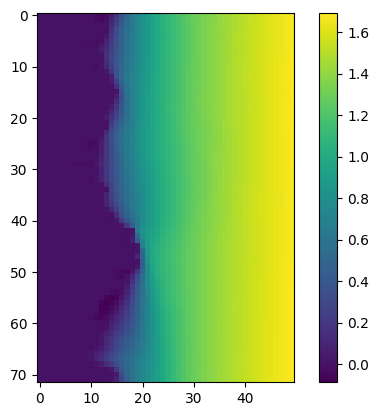

In [50]:
plt.imshow(a[0,0,0:N_x_sub,:].detach().cpu())
plt.colorbar()

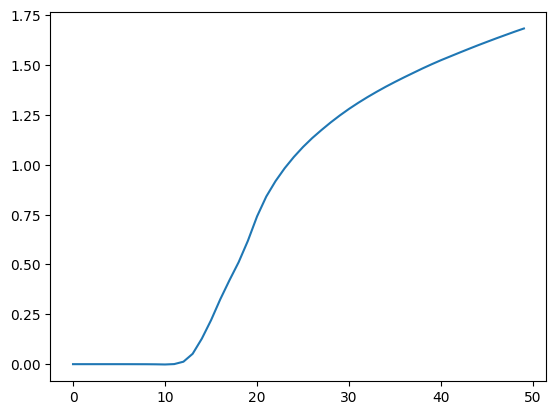

In [51]:
plt.plot(a[0,0,0:N_x_sub,:].detach().cpu().mean(axis=0))

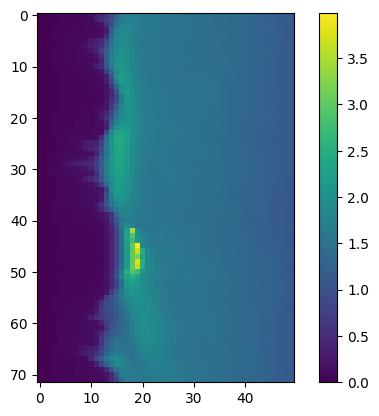

In [52]:
plt.imshow(a[0,2,0:N_x_sub,:].detach().cpu())
plt.colorbar()

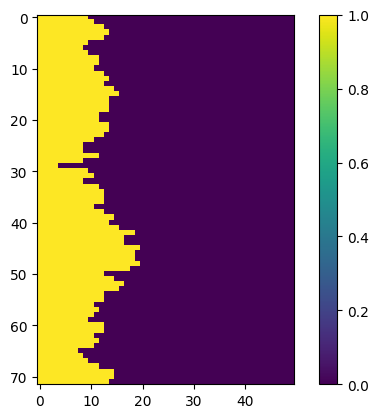

In [53]:
plt.imshow(a[0,5,0:N_x_sub,:].detach().cpu())
plt.colorbar()

In [54]:
torch.randint(5,(1,1))[0]

tensor([3])

In [ ]:
torch.set_float32_matmul_precision('medium')
comet_logger = pl_loggers.CSVLogger(save_dir="logs/")
trainer = pl.Trainer(gpus=1,# use one GPU
                     max_steps=50000, # iteration number
                     benchmark=True, # faster if input batch has constant size
                     logger=comet_logger, # for writting into tensorboard
                     log_every_n_steps=100,
                     enable_checkpointing=False,
                     limit_val_batches=0,
                        num_sanity_val_steps=0,
                    reload_dataloaders_every_n_epochs =1) # saving checkpoints ToDo: turn on checkpointing after first training phase
trainer.fit(solver)#,train_dataloaders=Disc_dataloader)

/usr/local/lib/python3.10/dist-packages/pytorch_lightning/trainer/connectors/accelerator_connector.py:478: LightningDeprecationWarning: Setting `Trainer(gpus=1)` is deprecated in v1.7 and will be removed in v2.0. Please use `Trainer(accelerator='gpu', devices=1)` instead.
  rank_zero_deprecation(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.10/dist-packages/pytorch_lightning/core/optimizer.py:273: RuntimeWarning: Found unsupported keys in the lr scheduler dict: {'factor', 'min_lr', 'patience', 'verbose'}. HINT: remove them from the output of `configure_optimizers`.
  rank_zero_warn(

  | Name             | Type                          | Params
-------------------------------------------------------------------
0 | generator        | FCN_model_Fourier_Feature_CNN | 1.7 M 
1 | discriminator    | ResNet                

Epoch 37:  37%|█████████████████▍                             | 37/100 [00:21<00:36,  1.73it/s, loss=2.2e+03, v_num=334]

In [ ]:
solver.train_dataloader()

In [ ]:
solver.trainer.current_epoch%1

In [ ]:
solver.N_dist

In [ ]:
6*144*91*5


In [ ]:
torch.save(model,"Flat_PIAN_CNN_OPT_Wasserstein.pt")

In [ ]:
a,_=next(iter(Disc_dataloader))
disc(a[:,:,0:72,:50])

In [ ]:
plt.imshow(a[0,0,0:36,:].detach().cpu())

In [ ]:
solver.coords.shape

In [ ]:
dist_new.shape

In [ ]:
a=solver(dist[0].expand((3,1,dist.shape[1])),dist_new[0].expand((3,1,dist_new.shape[1])),torch.tensor([1]).expand(3,1))

In [ ]:
a.shape

In [ ]:
plt.imshow(a[0,0,0:36,:].detach().cpu())

In [ ]:
def produce_sample(x_max,y_max,c,other_Constrains,resolution=100):
    list_x=np.linspace(0,x_max,resolution)
    list_y=np.linspace(0,y_max,resolution)
    XM,YM=np.meshgrid(list_x,list_y)
    model_value_x=np.zeros(XM.shape)
    model_value_y=np.zeros(XM.shape)    
    model_value_urms=np.zeros(XM.shape)
    model_value_uv=np.zeros(XM.shape)
    model_value_p=np.zeros(XM.shape)
    dist_1d=dist[c][None,None,:]
    for i in range(len(list_x)):
        for j in range(len(list_y)):
            coords = torch.tensor([[list_x[i],list_y[j],c]], dtype=torch.float32,device=GPU)
            model_value_x[i,j] = model(dist_1d,tp.spaces.Points(coords, X*Y*C)).as_tensor[0,0]
            model_value_y[i,j] = model(dist_1d,tp.spaces.Points(coords, X*Y*C)).as_tensor[0,1]
            model_value_urms[i,j] = model(dist_1d,tp.spaces.Points(coords, X*Y*C)).as_tensor[0,2]
            model_value_uv[i,j] = model(dist_1d,tp.spaces.Points(coords, X*Y*C)).as_tensor[0,4]
            model_value_p[i,j] = model(dist_1d,tp.spaces.Points(coords, X*Y*C)).as_tensor[0,5]
    model_value_urms=np.transpose(model_value_urms)
    model_value_uv=np.transpose(model_value_uv)
    model_value_x=np.transpose(model_value_x)
    model_value_y=np.transpose(model_value_y)
    model_value_p=np.transpose(model_value_p)
    plt.contourf(model_value_x,levels=10,extent=[0, x_max, 0, y_max],origin='lower')    
    plt.colorbar()
    plt.plot(x_corr.cpu(),dist[c].cpu())
    return model_value_x

In [ ]:
P=tp.spaces.Points(torch.tensor([[[1,2,3],[1,2,3],[4,5,6]]]), X*Y*C)

In [ ]:
plt.figure(figsize=(20,5))

model_values=produce_sample(3.6,1,0,200)
plt.title("predicted")

In [ ]:
plt.plot(torch.linspace(0,800,100)-0.043*800,model_values.mean(axis=1)/0.1402)
plt.plot(ys.detach().cpu()*800-0.043*800,a[0,0,:,:].detach().cpu().mean(axis=0)/0.1402)
plt.plot([0.45*800,0.45*800],[0,1.6])
plt.xscale("log")
x=torch.linspace(1,400,10)
y=1/0.38*torch.log(x)-3.5
plt.plot(x,y)
1/0.38

plt.plot(a[0,0,0:N_x_sub,:].detach().cpu().mean(axis=0))

In [ ]:
dist_1d=dist[0][None,None,:]
dist_1d=dist_1d.expand(8,-1,-1)
coords = torch.tensor([[0,0,0],[0,0,0],[0,0,0],[0,0,0],[0,0,0],[0,0,0],[0,0,0],[0,0,0]], dtype=torch.float32)
prediction=model(dist_1d,tp.spaces.Points(coords, X*Y*C)).as_tensor[:,0:5]
prediction

In [ ]:
torch.permute(prediction.reshape((1,4,2,5)),(0,3,1,2))

In [ ]:
dist_sub=dist[[0,1,2],:]
dist_sub=dist_sub[:,None,:]

In [ ]:
dist[[0,1,2],:]

In [ ]:
dist_input=dist_sub.expand(2*2,3,1,dist_sub.shape[2]).transpose(1,0).reshape((-1,1,dist_sub.shape[2]))

In [ ]:
dist_input

In [ ]:
model_values=produce_sample(2,2,100)


In [ ]:
for j in np.linspace(0,2,10):
    coords = torch.tensor([[j,i] for i in np.linspace(0,2,100)], dtype=torch.float32)
    model_out = model(tp.spaces.Points(coords, X*Y)).as_tensor
    for k in range(2,5):
        plt.plot(np.linspace(0,2,100),np.array(model_out.transpose(0,1)[k].tolist()))
    #plt.plot([0.4,0.4],[0.1,-0.1])

In [ ]:
coords = torch.tensor([[0,i] for i in np.linspace(0,2,100)], dtype=torch.float32)
model_out = model(tp.spaces.Points(coords, X*Y)).as_tensor
for k in range(2,5):
    plt.plot(np.linspace(0,2,100),np.array(model_out.transpose(0,1)[k].tolist()))
    #plt.plot([0.4,0.4],[0.1,-0.1])

In [ ]:
coords = torch.tensor([[1,i] for i in DF_Data["y"]], dtype=torch.float32)
model_out = model(tp.spaces.Points(coords, X*Y)).as_tensor
for k in range(2,4):
    plt.plot(DF_Data["y"],(np.array(model_out.transpose(0,1)[k].tolist())/6))
    #plt.plot([0.4,0.4],[0.1,-0.1])
plt.plot(DF_Data["y"],(np.array(model_out.transpose(0,1)[4].tolist())/60))
plt.plot(DF_Data["y"],DF_Data["urms"],'--')
plt.plot(DF_Data["y"],DF_Data["vrms"],'--')
plt.plot(DF_Data["y"],DF_Data["uv"],'--')
plt.scatter(ys,DF["urms"]/6,s=15)
plt.title("Reynolds stresses")
plt.savefig("stress.png")

In [ ]:
coords = torch.tensor([[1.8,i] for i in DF_Data["y"]], dtype=torch.float32)
model_out = model(tp.spaces.Points(coords, X*Y)).as_tensor
for k in range(0,2):
    plt.plot(DF_Data["y"],np.array(model_out.transpose(0,1)[k].tolist()))
    #plt.plot([0.4,0.4],[0.1,-0.1])
plt.plot(DF_Data["y"],DF_Data["U"],'--')
plt.plot(DF_Data["y"],DF_Data["V"],'--')
plt.scatter(ys,DF["U"],s=15)
plt.xscale("log")
plt.title("Mean profiles")
plt.savefig("mean.png")

In [ ]:
DF_Data

In [ ]:
for j in np.linspace(0,2,10):
    coords = torch.tensor([[j,i,20] for i in np.linspace(0,2,100)], dtype=torch.float32)
    model_out = model(tp.spaces.Points(coords, X*Y*H)).as_tensor
    plt.plot(np.linspace(0,2,100),np.array(model_out.transpose(0,1)[0].tolist()))
    plt.plot([0.3,0.3],[0.1,-0.1])

In [ ]:
coords = torch.tensor([[5,i] for i in np.linspace(0,2.0,100)], dtype=torch.float32)
model_out = model(tp.spaces.Points(coords, X*Y)).as_tensor
plt.plot(np.array(model_out.transpose(0,1)[0].tolist()))
coords = torch.tensor([[0,i] for i in np.linspace(0,2.0,100)], dtype=torch.float32)
model_out = model(tp.spaces.Points(coords, X*Y)).as_tensor
plt.plot(np.array(model_out.transpose(0,1)[0].tolist()))